# Lecture 3 — From totals to a defensible visual argument
## Decomposing change, comparing metrics, and testing the story

**Central question:** What changed in recorded passenger-car sales from 2023–24 to 2024–25, and how does the conclusion depend on the metric and visual representation?

This is a data-analysis and visualization class. Python and the optional SQL cell are computation tools, not the subject of the lecture.

**Analytical sequence:** question → audit → aggregate → decompose → visualize → stress-test → conclude.

**Class protocol:** predict the result, inspect the evidence, challenge the denominator, and defend one figure.

**Schedule:** 0–20 opening problem; 20–50 data audit; 50–75 live aggregation; 75–105 live metrics and one chart; 105–120 break; 120–145 benchmark and changed baseline; 145–170 group challenge; 170–180 defense and exit ticket.

In [1]:
# Google Colab only: download this lecture's data and helper files, then work inside that folder.
# Running locally? Start Jupyter in the lecture folder and this cell does nothing.
import os, sys
if 'google.colab' in sys.modules and not os.path.exists('requirements.txt'):
    !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/DrFarrukh/teaching.git /content/teaching
    !git -C /content/teaching sparse-checkout set courses/data-analysis-and-visualization/lectures/lecture-03
    os.chdir('/content/teaching/courses/data-analysis-and-visualization/lectures/lecture-03')
    !pip -q install -r requirements.txt
    print('Working folder:', os.getcwd())

## Learning outcomes

By the end of the class, students should be able to:

1. Translate a broad claim into a measurable comparison and stated denominator.
2. Decompose an aggregate change into manufacturer contributions and reconcile the parts to the whole.
3. Distinguish absolute change, relative growth, contribution to growth, share change, and benchmark-adjusted change.
4. Explain why valid metrics can rank the same manufacturers differently.
5. Select a visual encoding that matches the analytical task.
6. Test whether a conclusion survives a changed baseline or comparison period.
7. Write a conclusion that separates description, interpretation, and limitation.

## Opening problem — commit before computing

Recorded passenger-car sales increased from **81,579** in 2023–24 to **112,203** in 2024–25.

Before running code, write:

- the manufacturer you expect to have contributed the most additional units;
- whether you expect that manufacturer to have gained recorded share;
- the denominator for “contribution to the increase”;
- one reason why the largest percentage growth may not mean the largest practical contribution; and
- one claim these totals cannot support.

Keep the prediction. The objective is not to guess correctly; it is to make revision visible when evidence changes the story.

## 1. Setup and provenance

The monthly fact table was produced and validated in Lecture 2. It contains one row per **model group × measure × fiscal month**. A separate lookup maps each model-group label to one manufacturer.

The source is the local PAMA workbook snapshot already used in Lectures 1–2. All conclusions remain limited to the passenger-car records represented in that snapshot.

In [2]:
from pathlib import Path
import sqlite3

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (10, 5.8), "font.size": 11})

lecture_dir = Path.cwd()
if not (lecture_dir / "data" / "model_lookup.csv").is_file():
    lecture_dir = lecture_dir / "Lecture_3"

fact_path = lecture_dir / "data" / "passenger_cars_long.csv"
lookup_path = lecture_dir / "data" / "model_lookup.csv"
for required_path in (fact_path, lookup_path):
    if not required_path.is_file():
        raise FileNotFoundError(
            f"Missing {required_path}. Keep the notebook and data folder together "
            "and run it from the Lecture 3 folder."
        )
output_dir = lecture_dir / "outputs"
output_dir.mkdir(exist_ok=True)
print(fact_path)
print(lookup_path)

./data/passenger_cars_long.csv
./data/model_lookup.csv


In [3]:
fact = pd.read_csv(fact_path, parse_dates=["date"])
model_lookup = pd.read_csv(lookup_path)

print("Fact shape:", fact.shape)
print("Lookup shape:", model_lookup.shape)
display(fact.head(4))
display(model_lookup.head(6))

Fact shape: (4560, 10)
Lookup shape: (22, 2)


,model_group,measure,source_row,source_total,month,units,raw_units,date,fiscal_year,source_sheet
0,Honda Civic,Production,9,5813.0,Jul,554,554,2007-07-01,2007-08,2007-08
1,Honda Civic,Sales,10,5762.0,Jul,418,418,2007-07-01,2007-08,2007-08
2,Honda City,Production,12,8220.0,Jul,1046,1046,2007-07-01,2007-08,2007-08
3,Honda City,Sales,13,8439.0,Jul,611,611,2007-07-01,2007-08,2007-08


,model_group,manufacturer
0,BAIC D20,BAIC
1,BAIC D20 Sazgar,BAIC
2,Daihatsu Cuore,Daihatsu
3,Honda Cars (Civic & City),Honda
4,Honda City,Honda
5,Honda Civic,Honda


### Audit before analysis

Do not start with a chart. Establish what a row means, whether the join is valid, and whether the selected measure can be summed.

Required checks:

- 4,560 fact rows;
- 22 unique model-group labels in both inputs;
- one lookup row per model group;
- no unmatched fact keys;
- no duplicate analytical keys `(date, model_group, measure)`;
- nonnegative integer unit values; and
- Production and Sales remain separate measures.

In [4]:
audit = pd.Series({
    "fact_rows": len(fact),
    "fact_model_groups": fact["model_group"].nunique(),
    "lookup_rows": len(model_lookup),
    "lookup_unique_keys": model_lookup["model_group"].nunique(),
    "duplicate_fact_keys": fact.duplicated(["date", "model_group", "measure"]).sum(),
    "missing_units": fact["units"].isna().sum(),
    "negative_units": fact["units"].lt(0).sum(),
    "noninteger_units": fact["units"].dropna().mod(1).ne(0).sum(),
})
display(audit.to_frame("result"))

assert audit["fact_rows"] == 4560
assert audit["fact_model_groups"] == 22
assert audit["lookup_rows"] == audit["lookup_unique_keys"] == 22
assert audit[["duplicate_fact_keys", "missing_units", "negative_units", "noninteger_units"]].eq(0).all()

,result
fact_rows,4560
fact_model_groups,22
lookup_rows,22
lookup_unique_keys,22
duplicate_fact_keys,0
missing_units,0
negative_units,0
noninteger_units,0


In [5]:
joined = fact.merge(
    model_lookup,
    on="model_group",
    how="left",
    validate="many_to_one",
    indicator=True,
)

join_audit = pd.Series({
    "rows_before": len(fact),
    "rows_after": len(joined),
    "unmatched_rows": joined["manufacturer"].isna().sum(),
    "matched_rows": joined["_merge"].eq("both").sum(),
})
display(join_audit.to_frame("result"))

assert join_audit["rows_before"] == join_audit["rows_after"]
assert join_audit["unmatched_rows"] == 0

,result
rows_before,4560
rows_after,4560
unmatched_rows,0
matched_rows,4560


### Analytical contract

Today we compare **Sales**, not Production, in two completed fiscal years in the supplied snapshot.

Let:

- $x_{i,0}$ = manufacturer $i$ recorded sales in 2023–24;
- $x_{i,1}$ = manufacturer $i$ recorded sales in 2024–25;
- $X_0=\sum_i x_{i,0}$ and $X_1=\sum_i x_{i,1}$; and
- $\Delta_i=x_{i,1}-x_{i,0}$.

Every manufacturer-level change must reconcile to the total change:

$$\sum_i\Delta_i=X_1-X_0.$$

In [6]:
years = ["2023-24", "2024-25"]

selected = joined.loc[
    joined["measure"].eq("Sales") & joined["fiscal_year"].isin(years)
].copy()

annual = (
    selected.groupby(["manufacturer", "fiscal_year"], as_index=False)["units"]
            .sum()
)

comparison = (
    annual.pivot(index="manufacturer", columns="fiscal_year", values="units")
          .fillna(0)
          .rename_axis(columns=None)
)
comparison

,2023-24,2024-25
manufacturer,,
BAIC,0.0,4.0
Honda,11501.0,16614.0
Honri,0.0,186.0
Hyundai,2074.0,2954.0
Suzuki,51697.0,67233.0
Toyota,16307.0,25212.0


## 2. Start with the whole, then decompose it

An increase from 81,579 to 112,203 can be summarized as:

- an absolute increase of 30,624 recorded units; or
- relative growth of 37.54% from the earlier year.

Neither summary identifies who contributed to the increase or how the composition changed.

In [7]:
totals = comparison[years].sum()
total_change = totals["2024-25"] - totals["2023-24"]
market_growth = total_change / totals["2023-24"]

summary = pd.Series({
    "2023-24 recorded sales": totals["2023-24"],
    "2024-25 recorded sales": totals["2024-25"],
    "absolute change": total_change,
    "relative growth": market_growth,
})
display(summary.to_frame("value"))

assert total_change == 30624

,value
2023-24 recorded sales,81579.000000
2024-25 recorded sales,112203.000000
absolute change,30624.000000
relative growth,0.375391


### Build a metric table, not a single ranking

Each metric answers a different question:

$$\text{unit change: }\Delta_i=x_{i,1}-x_{i,0}$$

$$\text{contribution: }c_i=\frac{\Delta_i}{\sum_j\Delta_j}$$

$$\text{recorded share: }s_{i,t}=\frac{x_{i,t}}{\sum_jx_{j,t}}$$

$$\text{relative growth: }g_i=\frac{x_{i,1}-x_{i,0}}{x_{i,0}}$$

Relative growth is undefined when the baseline is zero. Do not silently convert that undefined rate to zero.

In [8]:
comparison["unit_change"] = comparison["2024-25"] - comparison["2023-24"]
comparison["contribution_pct"] = 100 * comparison["unit_change"] / total_change
comparison["share_2023_24_pct"] = 100 * comparison["2023-24"] / totals["2023-24"]
comparison["share_2024_25_pct"] = 100 * comparison["2024-25"] / totals["2024-25"]
comparison["share_change_pp"] = (
    comparison["share_2024_25_pct"] - comparison["share_2023_24_pct"]
)
comparison["relative_growth_pct"] = np.where(
    comparison["2023-24"].gt(0),
    100 * comparison["unit_change"] / comparison["2023-24"],
    np.nan,
)

metric_table = comparison.sort_values("unit_change", ascending=False)
display(metric_table.round(2))

assert metric_table["unit_change"].sum() == total_change
assert np.isclose(metric_table["contribution_pct"].sum(), 100)
assert np.isclose(metric_table["share_change_pp"].sum(), 0)

,2023-24,2024-25,unit_change,contribution_pct,share_2023_24_pct,share_2024_25_pct,share_change_pp,relative_growth_pct
manufacturer,,,,,,,,
Suzuki,51697.0,67233.0,15536.0,50.73,63.37,59.92,-3.45,30.05
Toyota,16307.0,25212.0,8905.0,29.08,19.99,22.47,2.48,54.61
Honda,11501.0,16614.0,5113.0,16.70,14.10,14.81,0.71,44.46
Hyundai,2074.0,2954.0,880.0,2.87,2.54,2.63,0.09,42.43
Honri,0.0,186.0,186.0,0.61,0.00,0.17,0.17,NaN
BAIC,0.0,4.0,4.0,0.01,0.00,0.00,0.00,NaN


### Retrieval check

Using the displayed metric table, answer before advancing:

1. Which manufacturer added the most recorded units?
2. Which incumbent manufacturer had the highest relative growth rate?
3. Which manufacturer gained the most recorded share?
4. How can the answer to Question 1 differ from Questions 2 and 3?
5. Why are the relative growth rates for zero-baseline entrants left undefined?

The key analytical lesson is **metric-dependent ranking**, not a single winner.

## 3. Visual question 1 — who supplied the additional units?

A ranked horizontal bar chart matches a comparison of signed magnitudes:

- position and length encode unit change;
- a zero line preserves direction;
- sorting reveals concentration;
- direct labels reduce lookup effort; and
- the title states the analytical result.

The chart does not show recorded share change. That requires a different view.

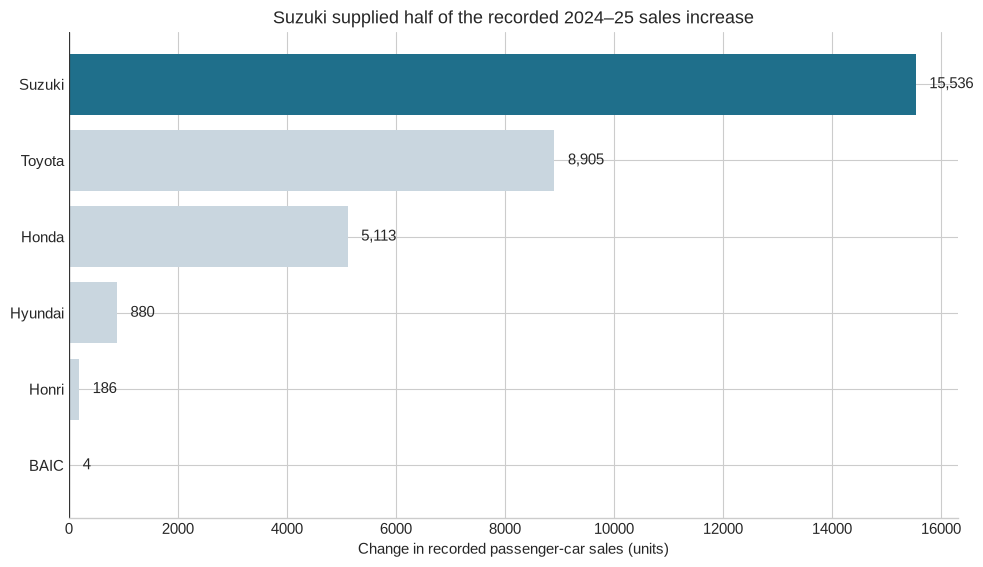

In [9]:
change_plot = metric_table.sort_values("unit_change")
colors = ["#c9d6df"] * len(change_plot)
colors[-1] = "#1f6f8b"

fig, ax = plt.subplots()
ax.barh(change_plot.index, change_plot["unit_change"], color=colors)
ax.axvline(0, color="#333333", linewidth=0.9)
for y, value in enumerate(change_plot["unit_change"]):
    ax.text(value + 250, y, f"{value:,.0f}", va="center")
ax.set(
    title="Suzuki supplied half of the recorded 2024–25 sales increase",
    xlabel="Change in recorded passenger-car sales (units)",
    ylabel="",
)
ax.spines[["top", "right", "left"]].set_visible(False)
plt.tight_layout()
fig.savefig(output_dir / "manufacturer_unit_change.png", dpi=200, bbox_inches="tight")
plt.show()

### Read the contribution chart carefully

- Suzuki added 15,536 recorded units, the largest absolute contribution.
- This equals about 50.7% of the total 30,624-unit increase.
- Toyota contributed about 29.1%; Honda contributed about 16.7%.
- The top three contributed approximately 96.5% of the increase.
- Every displayed manufacturer had a nonnegative change.
- Growth was broad in direction but concentrated in volume.
- None of these observations establishes why sales changed.

## 4. Visual question 2 — how did composition shift?

For two time points, a paired-dot or slope display shows both levels and direction:

- the horizontal position encodes recorded share;
- the connector encodes the direction and size of movement;
- common axes permit precise comparison;
- direct labels identify the years; and
- percentage points, not percent growth, describe the difference between shares.

A manufacturer can add units and still move left if the total grows faster.

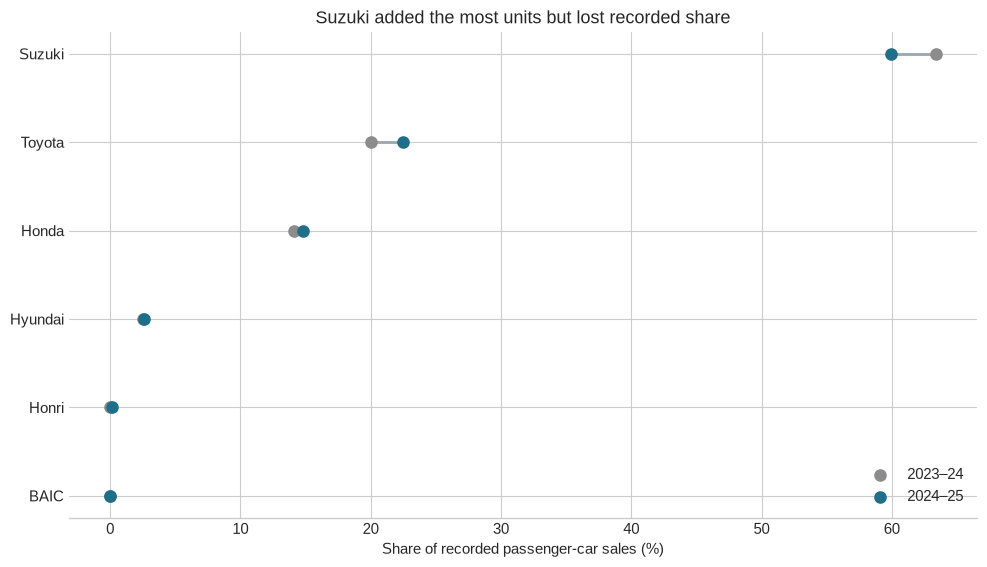

In [10]:
share_plot = metric_table.sort_values("share_2024_25_pct")
y = np.arange(len(share_plot))

fig, ax = plt.subplots()
for pos, (_, row) in zip(y, share_plot.iterrows()):
    ax.plot(
        [row["share_2023_24_pct"], row["share_2024_25_pct"]],
        [pos, pos], color="#9aa7b1", linewidth=2, zorder=1,
    )
ax.scatter(share_plot["share_2023_24_pct"], y, color="#8c8c8c", s=65,
           label="2023–24", zorder=2)
ax.scatter(share_plot["share_2024_25_pct"], y, color="#1f6f8b", s=65,
           label="2024–25", zorder=3)
ax.set_yticks(y, share_plot.index)
ax.set(
    title="Suzuki added the most units but lost recorded share",
    xlabel="Share of recorded passenger-car sales (%)",
    ylabel="",
)
ax.legend(frameon=False, loc="lower right")
ax.spines[["top", "right", "left"]].set_visible(False)
plt.tight_layout()
fig.savefig(output_dir / "recorded_share_shift.png", dpi=200, bbox_inches="tight")
plt.show()

### The second figure changes the story, not the data

- Suzuki’s recorded share fell from 63.37% to 59.92%.
- The decline was approximately 3.45 percentage points.
- Toyota gained approximately 2.48 percentage points.
- Honda gained approximately 0.71 percentage points.
- Suzuki grew in units but more slowly than the recorded total.
- “Largest contributor” and “share winner” are different analytical claims.
- The correct chart depends on which claim the audience must inspect.

## 5. An MS-level benchmark: growth expected from initial scale

Suppose every incumbent manufacturer grew at the overall recorded-market rate $g$.

The scale-based expected change is:

$$E_i=gx_{i,0}.$$

The benchmark-adjusted or mix shift is:

$$M_i=\Delta_i-E_i.$$

Positive $M_i$ means the manufacturer grew faster than the overall recorded total; negative $M_i$ means it grew more slowly. This is a descriptive counterfactual, not a causal estimate of competitiveness.

In [11]:
comparison["scale_expected_change"] = market_growth * comparison["2023-24"]
comparison["benchmark_adjusted_change"] = (
    comparison["unit_change"] - comparison["scale_expected_change"]
)

benchmark = comparison[
    ["unit_change", "scale_expected_change", "benchmark_adjusted_change"]
].sort_values("benchmark_adjusted_change", ascending=False)

display(benchmark.round(2))
print("Benchmark-adjusted changes sum to:",
      round(benchmark["benchmark_adjusted_change"].sum(), 10))
assert np.isclose(benchmark["benchmark_adjusted_change"].sum(), 0)

,unit_change,scale_expected_change,benchmark_adjusted_change
manufacturer,,,
Toyota,8905.0,6121.50,2783.50
Honda,5113.0,4317.37,795.63
Honri,186.0,0.00,186.00
Hyundai,880.0,778.56,101.44
BAIC,4.0,0.00,4.00
Suzuki,15536.0,19406.57,-3870.57


Benchmark-adjusted changes sum to: 0.0


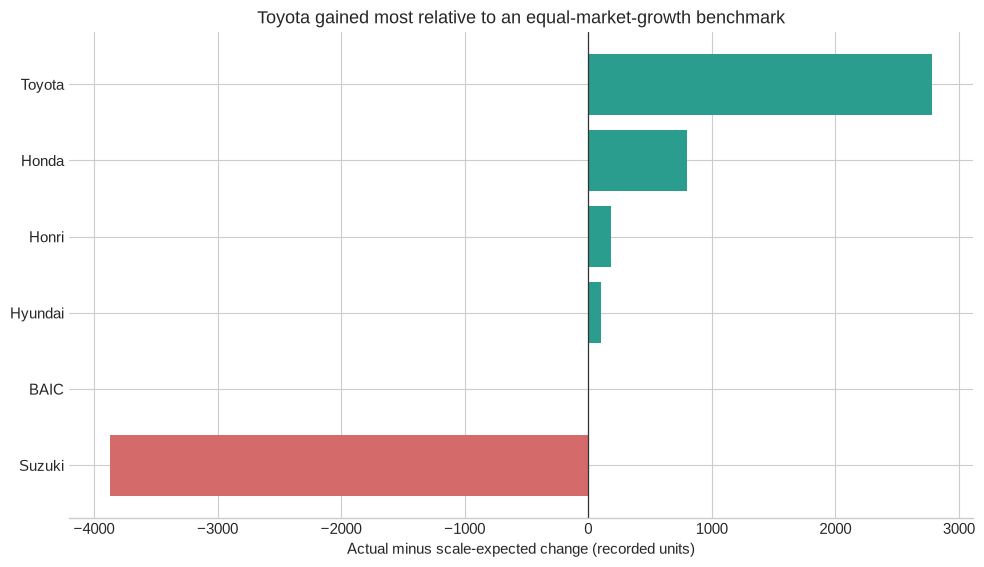

In [12]:
benchmark_plot = benchmark.sort_values("benchmark_adjusted_change")
colors = np.where(
    benchmark_plot["benchmark_adjusted_change"].ge(0), "#2a9d8f", "#d46a6a"
)

fig, ax = plt.subplots()
ax.barh(
    benchmark_plot.index,
    benchmark_plot["benchmark_adjusted_change"],
    color=colors,
)
ax.axvline(0, color="#333333", linewidth=0.9)
ax.set(
    title="Toyota gained most relative to an equal-market-growth benchmark",
    xlabel="Actual minus scale-expected change (recorded units)",
    ylabel="",
)
ax.spines[["top", "right", "left"]].set_visible(False)
plt.tight_layout()
fig.savefig(output_dir / "benchmark_adjusted_change.png", dpi=200, bbox_inches="tight")
plt.show()

### Three valid views now coexist

| Analytical question | Leading result | Appropriate evidence |
|---|---|---|
| Who added the most units? | Suzuki | Absolute-change bars |
| Who gained the most recorded share? | Toyota | Paired share dots |
| Who most exceeded scale-based growth? | Toyota | Benchmark-adjusted bars |

No result cancels another. They answer different questions.

The analytical error would be to compute one metric, label it as another, or select the metric only because it produces a preferred story.

## Break — 105–120 minutes

Before leaving, write one sentence completing each stem:

- “Absolute change is useful when …”
- “Recorded share change is useful when …”
- “The equal-growth benchmark assumes …”
- “The strongest unsupported causal claim would be …”

After the break, we test whether the conclusion depends on the chosen baseline.

## 6. Sensitivity to the comparison period

Calling 2024–25 a “rebound” embeds a baseline story. Compare three fiscal years:

- 2022–23 provides a pre-decline reference;
- 2023–24 is the low comparison year; and
- 2024–25 is the recovery year.

A conclusion is more informative when it reports whether the final level merely recovered the decline or exceeded the earlier reference.

In [13]:
three_years = ["2022-23", "2023-24", "2024-25"]
three_year = (
    joined.loc[
        joined["measure"].eq("Sales") & joined["fiscal_year"].isin(three_years)
    ]
    .groupby(["fiscal_year", "manufacturer"], as_index=False)["units"].sum()
)

three_totals = (
    three_year.groupby("fiscal_year")["units"].sum().reindex(three_years)
)
display(three_totals.to_frame("recorded_sales"))

print("2022–23 → 2023–24:", f"{three_totals['2023-24'] - three_totals['2022-23']:+,}")
print("2023–24 → 2024–25:", f"{three_totals['2024-25'] - three_totals['2023-24']:+,}")
print("2022–23 → 2024–25:", f"{three_totals['2024-25'] - three_totals['2022-23']:+,}")

,recorded_sales
fiscal_year,
2022-23,96811
2023-24,81579
2024-25,112203


2022–23 → 2023–24: -15,232
2023–24 → 2024–25: +30,624
2022–23 → 2024–25: +15,392


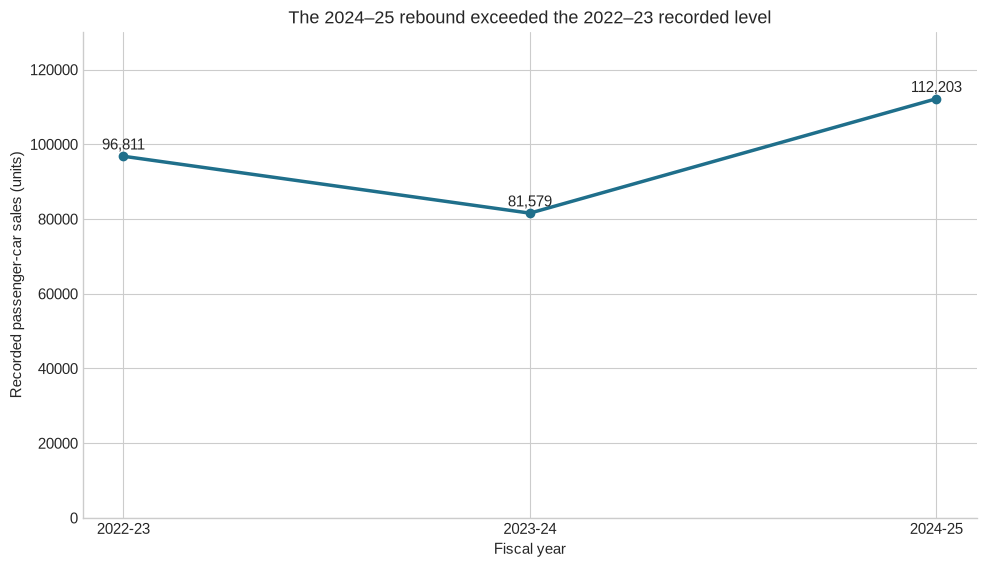

In [14]:
fig, ax = plt.subplots()
ax.plot(three_years, three_totals.values, marker="o", linewidth=2.5, color="#1f6f8b")
for x, value in zip(three_years, three_totals.values):
    ax.text(x, value + 1800, f"{value:,.0f}", ha="center")
ax.set(
    title="The 2024–25 rebound exceeded the 2022–23 recorded level",
    xlabel="Fiscal year",
    ylabel="Recorded passenger-car sales (units)",
)
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylim(0, three_totals.max() * 1.16)
plt.tight_layout()
fig.savefig(output_dir / "three_year_totals.png", dpi=200, bbox_inches="tight")
plt.show()

### Sensitivity finding

- Recorded sales fell by 15,232 units from 2022–23 to 2023–24.
- They then rose by 30,624 units in 2024–25.
- The 2024–25 level exceeded 2022–23 by 15,392 units.
- “Rebound from a low base” is accurate but incomplete.
- “Returned only to the old level” is contradicted by the supplied totals.
- A three-year view changes the strength and context of the conclusion.
- Coverage limitations remain; extra years do not repair source scope.

## 7. Concentration as a second-order question

Direction and concentration are different properties.

- The top three supplied 96.5% of the 2024–25 increase.
- The concentration ratio $CR_3$ measures the combined share of the three largest manufacturers.
- The Herfindahl–Hirschman Index is $HHI=\sum_i s_i^2$.
- A lower HHI indicates a less concentrated recorded distribution.
- The effective number $1/HHI$ translates concentration into an equivalent count of equal-sized manufacturers.
- These measures describe the recorded composition; they are not a legal competition assessment here.

In [15]:
concentration_rows = []
for year in years:
    shares = comparison[year] / comparison[year].sum()
    hhi = (shares ** 2).sum()
    concentration_rows.append({
        "fiscal_year": year,
        "CR3_pct": 100 * shares.nlargest(3).sum(),
        "HHI": hhi,
        "effective_number": 1 / hhi,
    })

concentration = pd.DataFrame(concentration_rows)
display(concentration.round(3))

,fiscal_year,CR3_pct,HHI,effective_number
0,2023-24,97.458,0.462,2.164
1,2024-25,97.198,0.432,2.314


### Concentration interpretation

- $CR_3$ changed little because Suzuki, Toyota, and Honda still dominate the records.
- HHI fell from about 0.462 to 0.432.
- The effective number rose from about 2.16 to 2.31 equal-sized manufacturers.
- The recorded distribution became modestly less concentrated by HHI.
- This is consistent with Suzuki’s share decline and Toyota’s gain.
- A lower HHI does not mean the market is unconcentrated.
- Report the measure and scope rather than using an unsupported label.

## Optional tool bridge — the aggregation engine can change

The analytical design should survive a change of tool. The next cell asks SQLite to produce the same manufacturer-year table. We are not studying SQL syntax today; we are checking that a different computation route reproduces the specified grain and totals.

Skip this cell if the room setup or timing makes it distracting.

In [16]:
with sqlite3.connect(":memory:") as connection:
    fact.drop(columns=["date"]).to_sql("fact_monthly", connection, index=False)
    model_lookup.to_sql("dim_model", connection, index=False)
    sql_annual = pd.read_sql_query(
        '''
        SELECT d.manufacturer, f.fiscal_year, SUM(f.units) AS units
        FROM fact_monthly AS f
        JOIN dim_model AS d ON f.model_group = d.model_group
        WHERE f.measure = 'Sales'
          AND f.fiscal_year IN ('2023-24', '2024-25')
        GROUP BY d.manufacturer, f.fiscal_year
        ''',
        connection,
    )

left = sql_annual.sort_values(["manufacturer", "fiscal_year"]).reset_index(drop=True)
right = annual.sort_values(["manufacturer", "fiscal_year"]).reset_index(drop=True)
pd.testing.assert_frame_equal(left, right, check_dtype=False)
print("Independent aggregation route agrees with the pandas result.")

Independent aggregation route agrees with the pandas result.


## 8. Independent challenge — was the rebound broad-based?

Groups of three must operationalize the word **broad-based** before calculating.

The class has already seen the 2023–24 → 2024–25 results. Your new calculation is the **manufacturer-level 2022–23 → 2024–25 comparison**. Decide whether the same definition of broad-based holds under both baselines.

Possible criteria include:

- most manufacturers increased;
- the top three contributed less than a chosen concentration threshold;
- recorded share gains were distributed across several manufacturers; or
- the conclusion holds under both the two-year and three-year views.

There is no credit for choosing a definition after seeing which one produces the preferred answer.

### Group deliverable

Submit one analytical panel containing:

1. a one-sentence operational definition of “broad-based”;
2. the metric and denominator;
3. one table with no more than six rows;
4. one figure selected for the claim;
5. a reconciliation to the 15,392-unit three-year net change and a comparison with the two-year result;
6. a two-sentence conclusion; and
7. one source-coverage or interpretation limitation.

Roles: analyst, visualization lead, and skeptical reviewer. Rotate roles next time.

In [17]:
# Group workspace — write your operational definition before calculating.
group_result = metric_table[[
    "2023-24",
    "2024-25",
    "unit_change",
    "contribution_pct",
    "share_change_pp",
]].copy()

# Example check: how much of the increase came from the three largest contributors?
top3_contribution = group_result.nlargest(3, "unit_change")["contribution_pct"].sum()
print("Top-three contribution (%):", round(top3_contribution, 2))

# Use `three_year` to compute each manufacturer's 2022–23 to 2024–25 change.
# Check that the manufacturer changes sum to 15,392 units.
# Compare the sign and largest contributor with the two-year result.
# Apply your chosen broad-based criterion consistently to both periods.
# Build exactly one figure and write a two-sentence conclusion below.

Top-three contribution (%): 96.51


## 9. Build the final visual argument

A figure is defensible when:

- its question is explicit;
- its denominator and unit are visible;
- its encoding supports the intended comparison;
- sorting and scales do not conceal contrary evidence;
- annotations identify the most decision-relevant value;
- the caption states coverage and time period; and
- removing the title would not make the visual ambiguous.

Choose one principal figure. More figures are not automatically more evidence.

### Claim structure

Use three layers:

1. **Description:** report the observed quantities and period.
2. **Interpretation:** explain the pattern created by the chosen comparison.
3. **Limitation:** state what the source or design cannot establish.

Avoid causal verbs such as *caused*, *drove demand*, or *won customers* unless the design contains evidence for those mechanisms.

Prefer: “Within the supplied PAMA passenger-car records …”

## Exit ticket

Answer in no more than six lines:

1. Name one pair of valid metrics that ranks the manufacturers differently.
2. Explain why the rankings differ.
3. State the single figure you would retain for the claim “who supplied the rebound?”
4. Give one reconciliation or sensitivity check.
5. Write one defensible descriptive claim.
6. Write one causal claim the data do not support.

## Before Lecture 4

- Save a clean notebook that runs from top to bottom.
- Retain the audit, metric table, one selected figure, and conclusion.
- Remove exploratory figures that do not support the final claim.
- Confirm your group of three and broad project domain.
- Bring one dataset example in which similar means may hide different distributions.
- Next question: **What does an average hide?**

Source context: https://pama.org.pk/monthly-production-sales-of-vehicles/